In [10]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import time # Importamos time para controlar la velocidad y no bloquear la API

# Configuración visual
%matplotlib inline
sns.set_theme(style="whitegrid")

API_KEY = "170265dcc664b1396cd1d6be03d32bc0"

# Lista manual expandida con muchas ciudades para hacer la base grande
ciudades = [
    # América del Sur
    "Lima", "Arequipa", "Trujillo", "Cusco", "Iquitos", "Piura", "Chiclayo", "Huancayo", "Tacna", "Pucallpa",
    "Buenos Aires", "Cordoba", "Rosario", "Mendoza", "Santiago", "Valparaiso", "Concepcion",
    "Bogota", "Medellin", "Cali", "Cartagena", "Quito", "Guayaquil", "La Paz", "Santa Cruz de la Sierra",
    "Brasilia", "Sao Paulo", "Rio de Janeiro", "Salvador", "Caracas", "Montevideo", "Asuncion",
    # América del Norte
    "New York", "Los Angeles", "Chicago", "Miami", "Houston", "Toronto", "Vancouver", "Mexico City", "Guadalajara", "Monterrey",
    # Europa
    "Madrid", "Barcelona", "Valencia", "Seville", "London", "Manchester", "Paris", "Marseille",
    "Berlin", "Munich", "Hamburg", "Rome", "Milan", "Naples", "Amsterdam", "Brussels", "Zurich", "Vienna",
    "Lisbon", "Porto", "Moscow", "Saint Petersburg", "Kyiv", "Warsaw", "Prague", "Budapest", "Athens", "Istanbul",
    # Asia y Oceanía
    "Tokyo", "Osaka", "Seoul", "Beijing", "Shanghai", "Hong Kong", "Bangkok", "Singapore", "Jakarta", 
    "New Delhi", "Mumbai", "Dubai", "Riyadh", "Sydney", "Melbourne", "Auckland",
    # África
    "Cairo", "Lagos", "Cape Town", "Johannesburg", "Nairobi", "Casablanca"
]

clima_raw = []

print(f"Comenzando descarga de datos para {len(ciudades)} ciudades...")

for i, ciudad in enumerate(ciudades):
    # Usamos try-except para que si una ciudad falla, el código siga con la siguiente
    try:
        url = f"https://api.openweathermap.org/data/2.5/weather?q={ciudad}&appid={API_KEY}&units=metric&lang=es"
        r = requests.get(url)
        
        if r.status_code == 200:
            data = r.json()
            clima_raw.append({
                "Ciudad": data["name"],
                "Pais": data["sys"]["country"],
                "Temp": data["main"]["temp"],
                "Temp_Min": data["main"]["temp_min"], # Agregué más datos para que sea más rica
                "Temp_Max": data["main"]["temp_max"],
                "Humedad": data["main"]["humidity"],
                "Presion": data["main"]["pressure"],
                "Viento": data["wind"]["speed"],
                "Nubosidad": data["clouds"]["all"],
                "Clima": data["weather"][0]["description"]
            })
            print(f"[{i+1}/{len(ciudades)}] ✔ {ciudad} descargado.")
        else:
            print(f"[{i+1}/{len(ciudades)}] ❌ Error con {ciudad}")
            
    except Exception as e:
        print(f"Error fatal en {ciudad}: {e}")
        
    # IMPORTANTE: La API gratis permite 60 llamadas por minuto. 
    # Hacemos una pausa de 1.1 segundos entre ciudades para no superar el límite.
    time.sleep(1.1)

# Crear DataFrame
df = pd.DataFrame(clima_raw)
df.to_csv("clima_datos.csv", index=False)
print("✔ Datos listos y guardados en 'clima_datos.csv'")
df.head()

Comenzando descarga de datos para 92 ciudades...
[1/92] ✔ Lima descargado.
[2/92] ✔ Arequipa descargado.
[3/92] ✔ Trujillo descargado.
[4/92] ✔ Cusco descargado.
[5/92] ✔ Iquitos descargado.
[6/92] ✔ Piura descargado.
[7/92] ✔ Chiclayo descargado.
[8/92] ✔ Huancayo descargado.
[9/92] ✔ Tacna descargado.
[10/92] ✔ Pucallpa descargado.
[11/92] ✔ Buenos Aires descargado.
[12/92] ✔ Cordoba descargado.
[13/92] ✔ Rosario descargado.
[14/92] ✔ Mendoza descargado.
[15/92] ✔ Santiago descargado.
[16/92] ✔ Valparaiso descargado.
[17/92] ✔ Concepcion descargado.
[18/92] ✔ Bogota descargado.
[19/92] ✔ Medellin descargado.
[20/92] ✔ Cali descargado.
[21/92] ✔ Cartagena descargado.
[22/92] ✔ Quito descargado.
[23/92] ✔ Guayaquil descargado.
[24/92] ✔ La Paz descargado.
[25/92] ✔ Santa Cruz de la Sierra descargado.
[26/92] ✔ Brasilia descargado.
[27/92] ✔ Sao Paulo descargado.
[28/92] ✔ Rio de Janeiro descargado.
[29/92] ✔ Salvador descargado.
[30/92] ✔ Caracas descargado.
[31/92] ✔ Montevideo descar

,Ciudad,Pais,Temp,Temp_Min,Temp_Max,Humedad,Presion,Viento,Nubosidad,Clima
0,Lima,PE,20.50,18.14,20.50,83,1013,2.57,0,cielo claro
1,Arequipa,PE,14.04,14.04,14.04,41,1015,0.00,0,cielo claro
2,Trujillo,PE,18.98,18.98,18.98,88,1012,2.57,47,nubes dispersas
3,Cusco,PE,7.13,7.13,7.13,81,1015,2.06,100,nubes
4,Iquitos,PE,25.02,25.02,25.02,94,1008,1.03,75,lluvia de gran intensidad



--- Análisis de Dispersión de la Temperatura ---
Variable: Temperatura diaria (°C)
🔹 Varianza: 63.71
🔹 Desviación Estándar: 7.98
🔹 Rango Intercuartílico (IQR): 12.00
   (Q1: 7.95 | Q3: 19.95)


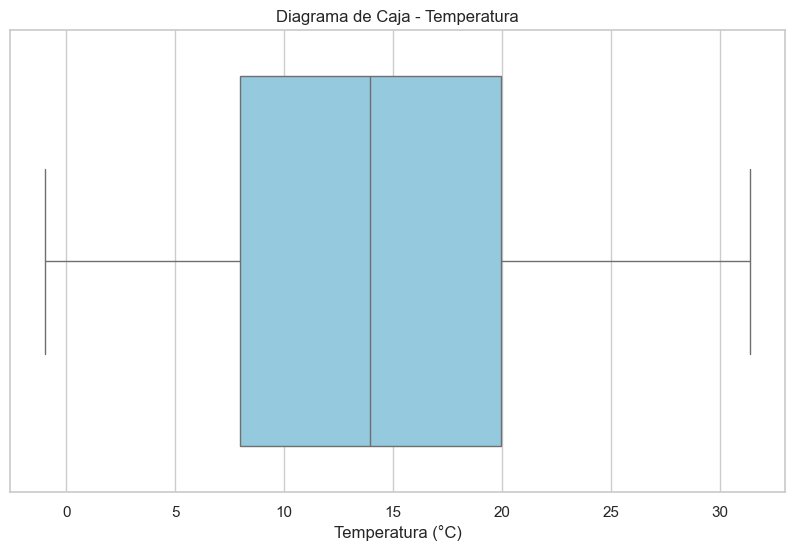


 Interpretación:
Los datos son relativamente homogéneos.


In [11]:
# ==========================================
# PARTE 2: MEDIDAS DE DISPERSIÓN 
# ==========================================

print("\n--- Análisis de Dispersión de la Temperatura ---")

# 1. Cálculo de las medidas
varianza = df["Temp"].var()
desviacion_std = df["Temp"].std()

# Cálculo del Rango Intercuartílico (IQR)
# Q1 = Percentil 25, Q3 = Percentil 75
Q1 = df["Temp"].quantile(0.25)
Q3 = df["Temp"].quantile(0.75)
IQR = Q3 - Q1

# Mostrar resultados numéricos
print(f"Variable: Temperatura diaria (°C)")
print(f"🔹 Varianza: {varianza:.2f}")
print(f"🔹 Desviación Estándar: {desviacion_std:.2f}")
print(f"🔹 Rango Intercuartílico (IQR): {IQR:.2f}")
print(f"   (Q1: {Q1:.2f} | Q3: {Q3:.2f})")

# 2. Visualización (Boxplot) para ver la dispersión y atípicos
plt.figure(figsize=(10, 6))
sns.boxplot(x=df["Temp"], color="skyblue")
plt.title("Diagrama de Caja - Temperatura")
plt.xlabel("Temperatura (°C)")
plt.show()

# Interpretación rápida automática
print("\n Interpretación:")
if desviacion_std > 10:
    print("Los datos están MUY dispersos (hay climas muy extremos entre ciudades).")
else:
    print("Los datos son relativamente homogéneos.")

--- ANÁLISIS DE NORMALIDAD ---
P-valor obtenido: 0.0878
Resultado: Los datos son NORMALES (Usar pruebas paramétricas)


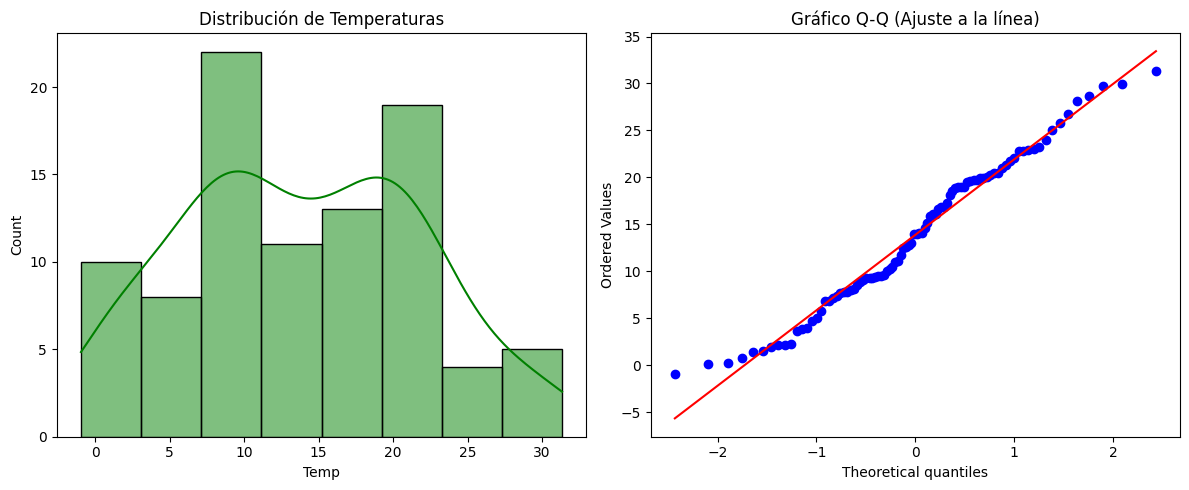

In [1]:
# ==========================================
# PARTE 4: SUPUESTO DE NORMALIDAD
# ==========================================
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Cargar los datos generados por el integrante 1
try:
    df = pd.read_csv("clima_datos.csv")
    datos_temp = df["Temp"]

    print("--- ANÁLISIS DE NORMALIDAD ---")

    # 2. Prueba de Shapiro-Wilk
    stat, p_valor = stats.shapiro(datos_temp)
    print(f"P-valor obtenido: {p_valor:.4f}")

    # 3. Veredicto técnico
    if p_valor > 0.05:
        resultado = "NORMALES"
        print("Resultado: Los datos son NORMALES (Usar pruebas paramétricas)")
    else:
        resultado = "NO NORMALES"
        print("Resultado: Los datos NO son normales (Usar pruebas NO paramétricas)")

    # 4. Gráficas visuales
    plt.figure(figsize=(12, 5))

    # Histograma para ver la "campana"
    plt.subplot(1, 2, 1)
    sns.histplot(datos_temp, kde=True, color="green")
    plt.title("Distribución de Temperaturas")

    # Gráfico Q-Q para ver la alineación
    plt.subplot(1, 2, 2)
    stats.probplot(datos_temp, dist="norm", plot=plt)
    plt.title("Gráfico Q-Q (Ajuste a la línea)")

    plt.tight_layout()
    plt.show()

except FileNotFoundError:
    print("ERROR: Primero debes ejecutar la celda del Integrante 1 para generar el archivo CSV.")